# Load libraries

In [14]:
# Usuals
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import set_config

# Load Dataset

In [2]:
# load csv
df = pd.read_csv("../Addiction_Prediction_Project/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
display(df.head(10))
df.shape

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
5,TXN00006,U00006,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe,1
6,TXN00007,U00007,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe,1
7,TXN00008,U00008,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate,1
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN,0
9,TXN00010,U00010,35,Other,9.76,4.73,1.36,2.11,5.21,20,82,12.69,Low,Yes,Severe,1


(7500, 16)

# Defined Objective:
- Whether a person will be addicted to smartphone usage or not be addicted to smartphone usage?
- This is a worldwide current hot topic because of all the ongoing lawsuits against Meta and others for addiction amongst teens and young adults, and the impact is currently having.
- Binary problem:
    - 0 = not addicted
    - 1 = addicted

### Features Included:
- Demographics (Age, Gender)
- Daily Screen Time Metrics
- Social Media & Gaming Usage
- Productivity & Academic Impact
- Sleep Patterns
- Notification & App Interaction Metrics
- Stress Levels
- Addiction Severity Label

### Source:
- https://www.kaggle.com/datasets/jayjoshi37/smartphone-usage-and-addiction-prediction/data

> The dataset **simulates** real-world behavioral data

***

# EDA

,count,percent
addicted_label,,
0,2192,29.23
1,5308,70.77


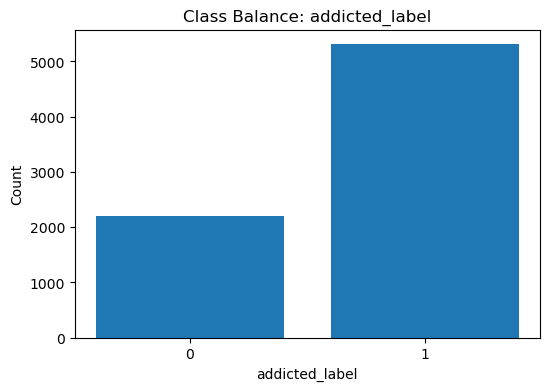

In [4]:
# class balance: counts + percentages
class_counts = df["addicted_label"].value_counts().sort_index()
class_percent = df["addicted_label"].value_counts(normalize=True).sort_index() * 100

class_balance = pd.DataFrame({
    "count": class_counts,
    "percent": class_percent.round(2)
})

display(class_balance)

# simple bar chart
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Balance: addicted_label")
plt.xlabel("addicted_label")
plt.ylabel("Count")
plt.show()

In [11]:
# when does an addiction level become classified as an addiction?
display(
    pd.crosstab(
        df["addiction_level"].fillna("Missing"),
        df["addicted_label"]
    )
)

addicted_label,0,1
addiction_level,,
Mild,1373,0
Missing,819,0
Moderate,0,2874
Severe,0,2434


- Our target needs to either be `addicted_level` or `addicted_label` as we can see clear data leakage.

## We want to better understand the synthetic dataset to aid contextual narrative.

In [62]:
# EDA reusable structure

target_col = "addicted_label"
id_cols = ["transaction_id", "user_id"]
leakage_cols = ["addiction_level"]

num_cols = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

cat_cols = [
    "stress_level",
    "academic_work_impact",
    "gender"
]

feature_cols = num_cols + cat_cols

X = df[feature_cols].copy()
y = df[target_col].copy()

- Setup objects for rest of EDA workflow simplicity

In [65]:
# Compare numeric features by target

target_summary = (
    df.groupby(target_col)[num_cols]
      .mean()
      .T
      .rename(columns={0: "not_addicted_mean", 1: "addicted_mean"})
)

target_summary["difference"] = (
    target_summary["addicted_mean"] - target_summary["not_addicted_mean"]
)

display(target_summary.sort_values("difference", ascending=False))

addicted_label,not_addicted_mean,addicted_mean,difference
weekend_screen_time,6.894535,10.213994,3.319459
daily_screen_time_hours,5.156861,8.467502,3.310641
social_media_hours,2.251615,3.695477,1.443862
app_opens_per_day,97.000456,98.175961,1.175505
sleep_hours,6.666665,6.766839,0.100174
age,26.534672,26.582894,0.048222
gaming_hours,1.999051,2.020431,0.021380
work_study_hours,3.239672,3.243555,0.003883
notifications_per_day,134.325730,134.229088,-0.096642


- weekend_screen_time 
- daily_screen_time_hours 
- social_media_hours 
> These each have substantial differences in the scope of day to day life. With ~17.5 hours on average awake, these habits take up a substantial amount.

In [66]:
# Percent tables for categorical variables

for col in cat_cols:
    print(f"\n{col} vs {target_col}")
    display(pd.crosstab(df[col], y, normalize="index").round(3))


gender vs addicted_label


addicted_label,0,1
gender,,
Female,0.298,0.702
Male,0.278,0.722
Other,0.302,0.698



stress_level vs addicted_label


addicted_label,0,1
stress_level,,
High,0.296,0.704
Low,0.288,0.712
Medium,0.292,0.708



academic_work_impact vs addicted_label


addicted_label,0,1
academic_work_impact,,
No,0.292,0.708
Yes,0.292,0.708


- gender
- stress_level
- academic_work_impact

> These categorical variables do not appear to separate addicted from non-addicted users, since each category closely follows the overall class balance.

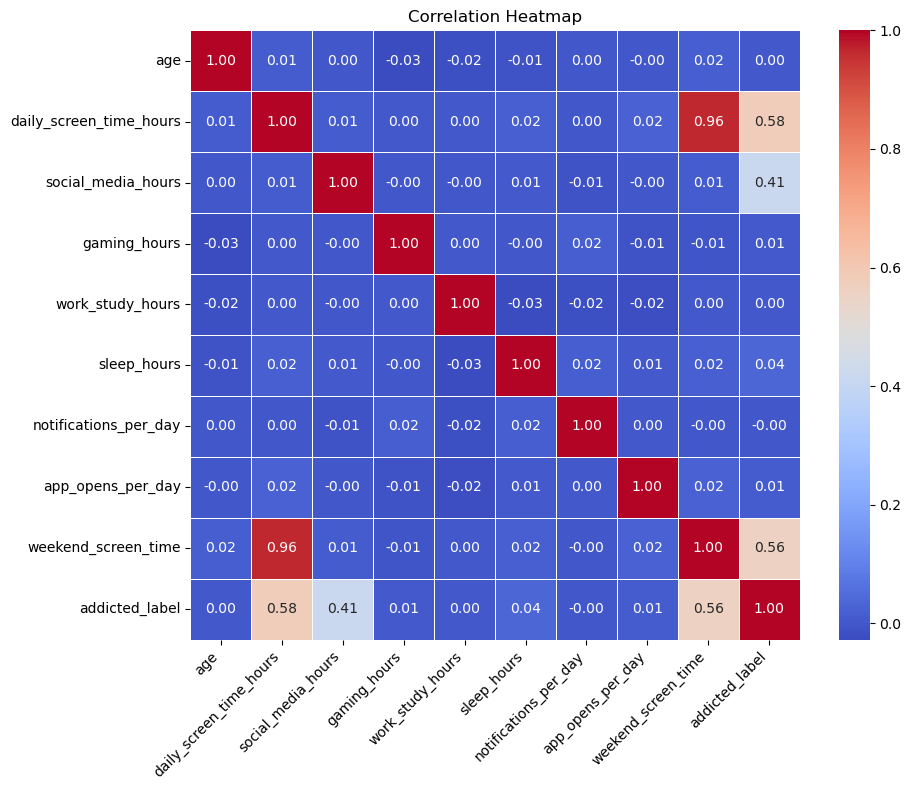

In [67]:
# Correlation heatmap (numeric features + target)

corr_matrix = df[num_cols + [target_col]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Correlation heatmap
- `daily_screen_time`, `weekend_screen_time`, and `social_media_hours` have moderate correlations with the `addicted_label`
- `weekend_screen_time` and `daily_screen_time_hours` are extremely positively correlated (r = 0.96) ; suggesting substantial redundancy

In [68]:
set_config(transform_output="pandas")

pre = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", "passthrough", num_cols)
])

X_probe_encoded = pre.fit_transform(X)

probe_tree = DecisionTreeClassifier(max_depth=2, random_state=999)
probe_tree.fit(X_probe_encoded, y)

print(export_text(probe_tree, feature_names=list(X_probe_encoded.columns)))
print("Probe tree training accuracy:", round(probe_tree.score(X_probe_encoded, y), 4))

|--- num__daily_screen_time_hours <= 7.97
|   |--- num__social_media_hours <= 4.01
|   |   |--- class: 0
|   |--- num__social_media_hours >  4.01
|   |   |--- class: 1
|--- num__daily_screen_time_hours >  7.97
|   |--- num__weekend_screen_time <= 8.56
|   |   |--- class: 0
|   |--- num__weekend_screen_time >  8.56
|   |   |--- class: 1

Probe tree training accuracy: 0.9384


### Features that likely constructed addicted binary target
- daily_screen_time_hours 
- social_media_hours 
- weekend_screen_time 

> daily_screen_time_hours @7.97 is biggest split 

In [69]:
# Top 3 numeric drivers based on mean difference

top_features = (
    target_summary.sort_values("difference", ascending=False)
                  .head(3)
                  .index
                  .tolist()
)

print("Top features:", top_features)

Top features: ['weekend_screen_time', 'daily_screen_time_hours', 'social_media_hours']


In [73]:
# Summary tables for the top features

for feature in top_features:
    feature_summary = (
        df.groupby(target_col)[feature]
          .agg(["mean", "median", "std", "min", "max"])
          .round(2)
    )
    
    print(f"\nSummary for {feature}")
    display(feature_summary)


Summary for weekend_screen_time


,mean,median,std,min,max
addicted_label,,,,,
0,6.89,6.79,1.54,3.58,10.81
1,10.21,10.58,2.50,3.66,14.88



Summary for daily_screen_time_hours


,mean,median,std,min,max
addicted_label,,,,,
0,5.16,5.06,1.35,3.00,8.0
1,8.47,8.84,2.38,3.01,12.0



Summary for social_media_hours


,mean,median,std,min,max
addicted_label,,,,,
0,2.25,2.28,1.02,0.5,4.0
1,3.70,4.06,1.58,0.5,6.0


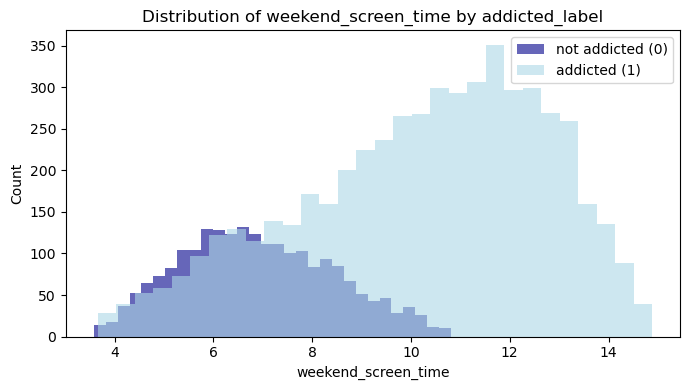

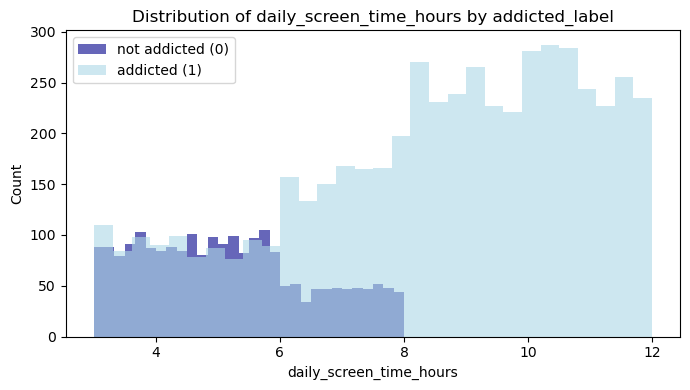

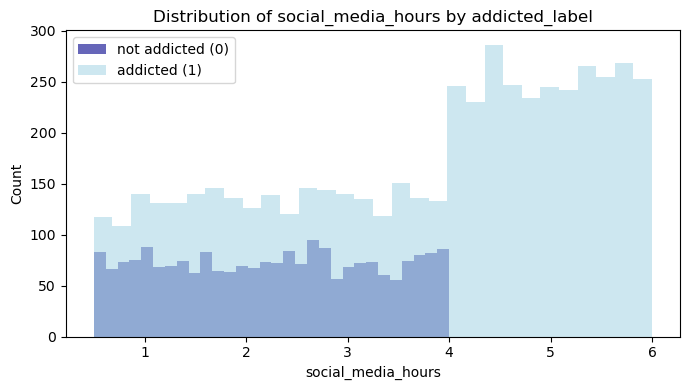

In [71]:
# Histograms by target class for the top features

for feature in top_features:
    plt.figure(figsize=(7, 4))
    
    plt.hist(
        df.loc[y == 0, feature],
        bins=30,
        alpha=0.6,
        label="not addicted (0)",
        color="darkblue"
    )
    plt.hist(
        df.loc[y == 1, feature],
        bins=30,
        alpha=0.6,
        label="addicted (1)",
        color="lightblue"
    )
    
    plt.title(f"Distribution of {feature} by {target_col}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Not addicted ; Upper bound thresholds
- daily_screen_time_hours: tops out at 8.0
- social_media_hours: tops out at 4.0
- weekend_screen_time is more nuanced. Typically, people are not working weekends and just want to relax, which gives way to different expected hours.

### Addicted ; 
- Among addicted individuals they may fall within the min and max bounds within this dataset, suggesting a combination of factors rather than one behavioral pattern giving way.


## EDA Conclusion
The distributions suggest that `addicted_label` is largely constructed from screen-use intensity variables rather than broader behavioral or psychological features. In particular, `daily_screen_time_hours` and `social_media_hours` show apparent threshold behavior, with the non-addicted class capped at 8.0 and 4.0 respectively. However, because addicted cases still occur below those values, the label appears to follow a combined decision rule rather than a single hard cutoff. `weekend_screen_time` contributes additional separation but does not display the same sharp boundary.

---